# 1. nan Error analysis

In [1036]:
import import_ipynb
import L_layer_model
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

## 1.1 Why did 'nan' occur?

In [1037]:
X_train = L_layer_model.X[:, 0].reshape(784, 1)
y_train = L_layer_model.y_one_hot[:, 0].reshape(10, 1)
node_num_list = [784, 500, 100, 10]
parameters = L_layer_model.initialize_weight(node_num_list)
y_hat, cache = L_layer_model.forward_propagation(X_train, parameters)
print(cache['Z3'])

[[ -712.92876656]
 [-1529.80059233]
 [ -542.57865898]
 [ 1406.50720761]
 [ -376.19355337]
 [ 1944.49482921]
 [-1024.41580728]
 [ 2198.9063465 ]
 [  512.52036113]
 [ -698.25779273]]


In [1038]:
#softmax
Z3 = cache['Z3']
print(cp.exp(Z3))
print('sum:', sum(cp.exp(Z3)))
print(y_hat)

[[2.39315426e-310]
 [0.00000000e+000]
 [2.29658439e-236]
 [            inf]
 [4.18037888e-164]
 [            inf]
 [0.00000000e+000]
 [            inf]
 [3.84383469e+222]
 [5.62980914e-304]]
sum: [inf]
[[ 0.]
 [ 0.]
 [ 0.]
 [nan]
 [ 0.]
 [nan]
 [ 0.]
 [nan]
 [ 0.]
 [ 0.]]


The reason why nan was made was because of inf / inf

## 1.2 Why did 'inf' occur?

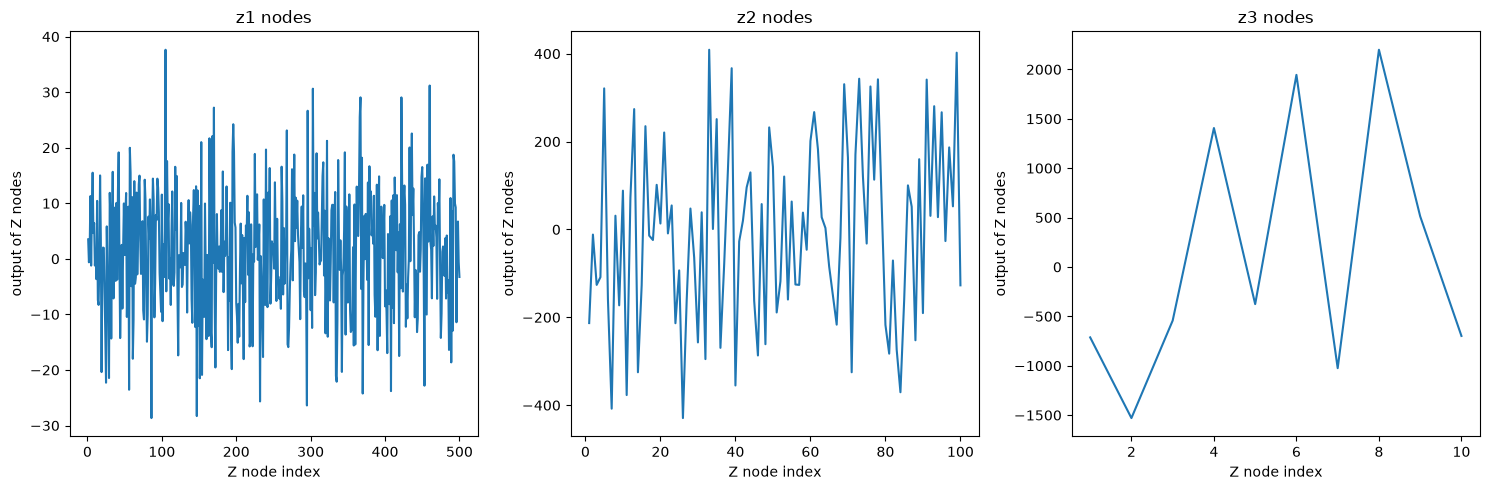

In [1039]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    Z = cache[f'Z{i+1}'].get()
    ax.plot(np.arange(1, len(Z)+1), Z)
    ax.set_title(f'z{i+1} nodes')
    ax.set_xlabel('Z node index')
    ax.set_ylabel('output of Z nodes')
plt.tight_layout()
plt.show()

In [1040]:
print(f'mean: {cp.mean(cache['Z3'])}, var: {cp.var(cache['Z3'])}')

mean: 117.82535732104785, var: 1553982.2919399557


The reason why inf was made was because of high variance of Z3

## 1.3 Solution (scaling down weights)

We can reduce variance with scaleing down the weights

In [1041]:
node_num_list = [784, 500, 100, 10]
parameters = L_layer_model.initialize_weight(node_num_list)
#before scaling down
print('before scaling down')
for i in range(1, 4):
    print(f'mean of W{i}: {cp.mean(parameters[f'W{i}'])}')
    print(f'variance of W{i}: {cp.var(parameters[f'W{i}'])}')
    print('')

print('after scaling down')
for i in range(1, 4):
    parameters[f'W{i}'] *= 0.1
    print(f'mean of W{i}: {cp.mean(parameters[f'W{i}'])}')
    print(f'variance of W{i}: {cp.var(parameters[f'W{i}'])}')
    print('')

before scaling down
mean of W1: 0.00015764331546696145
variance of W1: 1.000932818778941

mean of W2: -0.004754727998454461
variance of W2: 0.9986899150053017

mean of W3: 0.04373418226874479
variance of W3: 0.9934703951890727

after scaling down
mean of W1: 1.5764331546696097e-05
variance of W1: 0.01000932818778941

mean of W2: -0.0004754727998454462
variance of W2: 0.009986899150053019

mean of W3: 0.004373418226874479
variance of W3: 0.009934703951890727



In [1042]:
y_hat, cache = L_layer_model.forward_propagation(X_train, parameters)
print(y_hat)

[[0.01054894]
 [0.18108273]
 [0.02276897]
 [0.02468759]
 [0.01701713]
 [0.05382228]
 [0.62898378]
 [0.03647581]
 [0.01772667]
 [0.00688609]]


We can check there is no 'inf' if weight is small

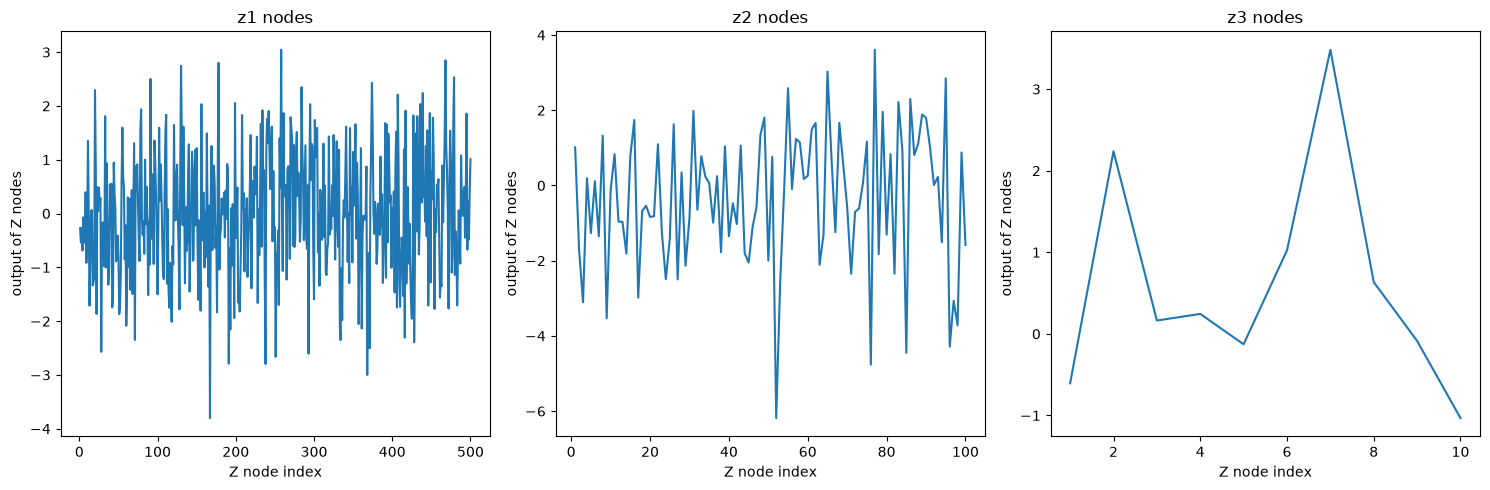

In [1043]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    Z = cache[f'Z{i+1}'].get()
    ax.plot(np.arange(1, len(Z)+1), Z)
    ax.set_title(f'z{i+1} nodes')
    ax.set_xlabel('Z node index')
    ax.set_ylabel('output of Z nodes')
plt.tight_layout()
plt.show()

We can check that variance of Z3 is maintained if weight is small

# 2. How about deeper model

In [1048]:
node_num_list = [784] + [500]*19 + [10] # 20 layer model

# initialize parameters
parameters = L_layer_model.initialize_weight(node_num_list)
for i in range(1, len(parameters)//2+1):
    parameters[f'W{i}'] *= 0.1

In [1049]:
X_train = L_layer_model.X[:, :500]
y_train = L_layer_model.y_one_hot[:, :500]

X_val = L_layer_model.X[:, :]
y_val = L_layer_model.y_one_hot[:, :]

y_hat, cache = L_layer_model.forward_propagation(X_train, parameters)
print('y_hat: ', y_hat[:, 0])

y_hat:  [ 0.  0. nan  0.  0. nan nan nan  0.  0.]


If the model is deep, we encounter the NaN error again."

variance of Z1: 0.9278
variance of Z10: 3030.2291
variance of Z20: 15821434.665


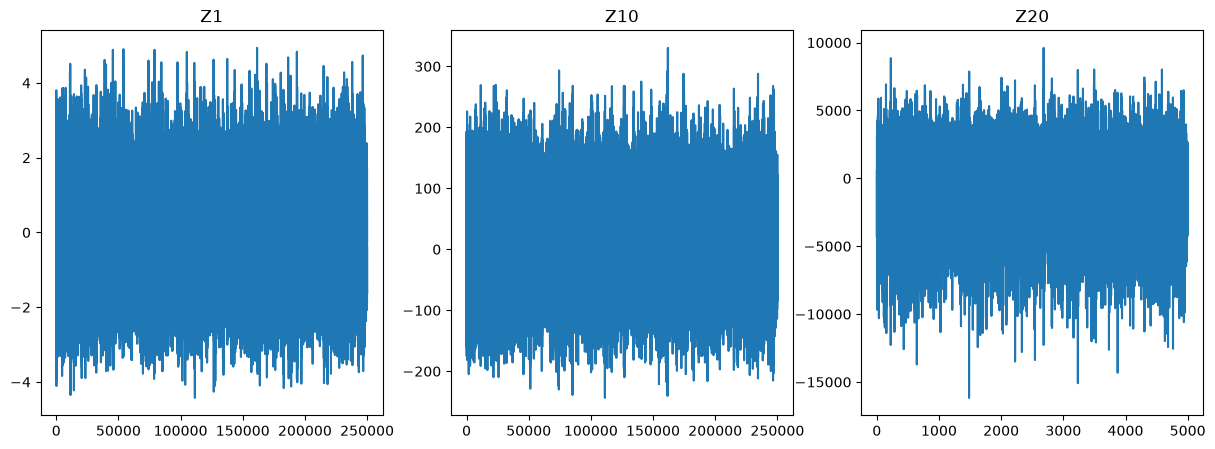

In [1052]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
col = 0
for i in range(1, len(node_num_list)):
    if i == 1 or i % 10 == 0:
        ax = axes[col]
        Z = cache[f'Z{i}'].T.flatten().get()
        ax.plot(np.arange(1, len(Z)+1), Z)
        ax.set_title(f'Z{i}')
        col += 1

z_var_list = [1, 10, 20]
for i in z_var_list:
    print(f'variance of Z{i}: {cp.round(cp.var(cache[f'Z{i}']), 4)}')

Comparing Z1, Z10, and Z20, we can see that as Z gets larger, its variance also increases. Therefore, we found that the large variance in Z20 leads to a NaN error.

# 3. How about smaller weight

In [1053]:
parameters = L_layer_model.initialize_weight(node_num_list)
# variance of W: 0.01 -> 0.0001
for i in range(1, len(parameters)//2+1):
    parameters[f'W{i}'] *= 0.01
    
print('variance of W1: ', cp.round(cp.var(parameters['W1']), 5))
model = L_layer_model.Model(node_num_list)
model.parameters = parameters
epoches = 1000
train_loss, _ = model.train(X_train, y_train, X_train, y_train, 0.01, epoches, True)

variance of W1:  0.0001
cost of 0th epoch: 2.3026
cost of 100th epoch: 2.3008
cost of 200th epoch: 2.2994
cost of 300th epoch: 2.2982
cost of 400th epoch: 2.2972
cost of 500th epoch: 2.2964
cost of 600th epoch: 2.2958
cost of 700th epoch: 2.2953
cost of 800th epoch: 2.2949
cost of 900th epoch: 2.2945


When I multiplied $W$ by 0.01, the model started training.

But if the weights are smaller, the loss decreases too slowly

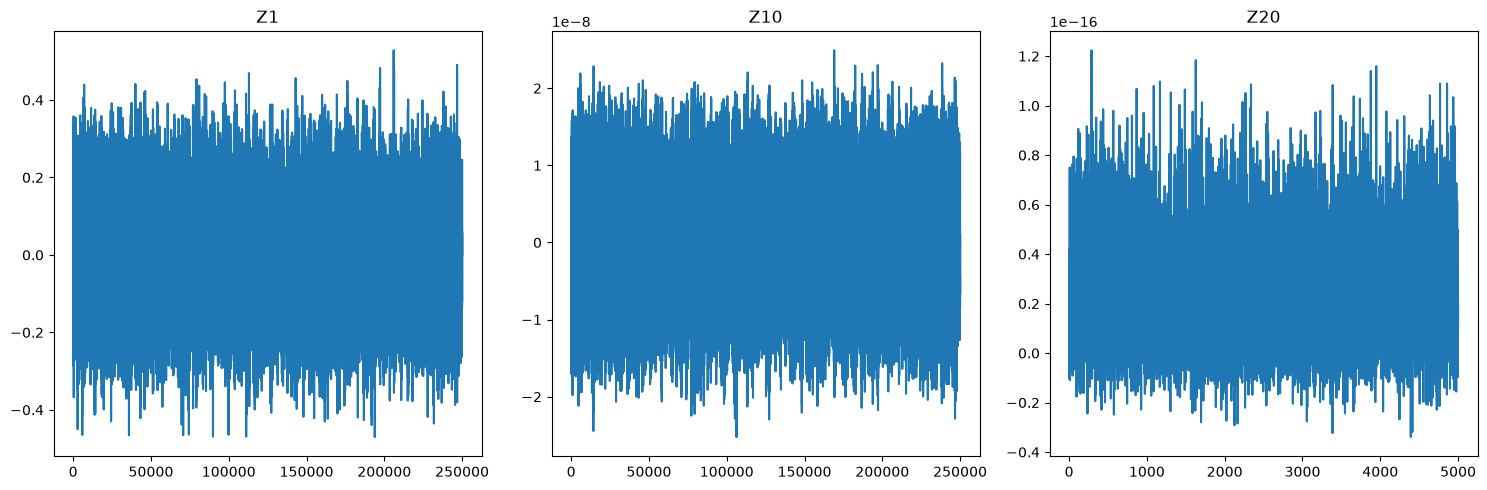

variance of Z1: 0.0092
variance of Z10: 0.0
variance of Z20: 0.0


In [1060]:
parameters = L_layer_model.initialize_weight(node_num_list)
for i in range(1, len(parameters)//2+1):
    parameters[f'W{i}'] *= 0.01
y_hat, cache = L_layer_model.forward_propagation(X_train, parameters)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
col = 0
for i in range(1, len(node_num_list)):
    if i == 1 or i % 10 == 0:
        ax = axes[col]
        Z = cache[f'Z{i}'].T.flatten().get()
        ax.plot(np.arange(1, len(Z)+1), Z)
        ax.set_title(f'Z{i}')
        col += 1
plt.tight_layout()
plt.show()

for i in z_var_list:
    print(f'variance of Z{i}: {cp.round(cp.var(cache[f'Z{i}']), 4)}')

With smaller weights, we can see that as Z gets larger, its variance also increases.

This means that dZ20 is almost 0.

So, dW and db are almost 0 too (due to backpropagation).

## 3.1 Trace backpropagation

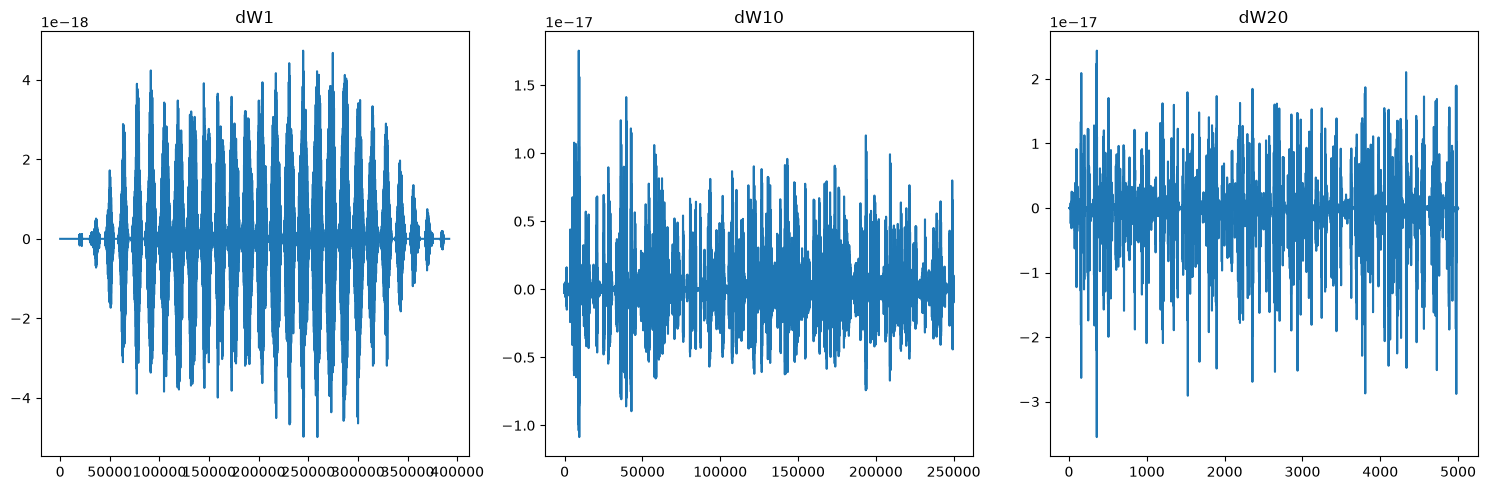

mean of dW1: -0.0
variance of dW1: 0.0
mean of dW10: 0.0
variance of dW10: 0.0
mean of dW20: 0.0
variance of dW20: 0.0


In [1059]:
grads = L_layer_model.back_propagation(y_hat, y_train, parameters, cache)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
col = 0
for i in range(1, len(node_num_list)):
    if i == 1 or i % 10 == 0:
        ax = axes[col]
        dW = grads[f'dW{i}'].T.flatten().get()
        ax.plot(np.arange(1, len(dW)+1), dW)
        ax.set_title(f'dW{i}')
        col += 1

plt.tight_layout()
plt.show()

dw_list = [1, 10, 20]
for i in dw_list:
    print(f'mean of dW{i}: {cp.round(cp.mean(grads[f'dW{i}']), 10)}')
    print(f'variance of dW{i}: {cp.round(cp.var(grads[f'dW{i}']), 10)}')

We found that because dW is almost 0, the parameters are not updated

Therefore, variance of weight should not be too large or too small

# 5. What is best Weight initialization (He initialization)

In [1061]:
# a number of node in layer is 1000(input), 100, 100, 10
X_train = cp.random.randn(1000, 100000)
W1 = cp.random.randn(1000, 1000)
W2 = cp.random.randn(1000, 1000)
W3 = cp.random.randn(10, 1000)
Z1 = W1 @ X_train
Z2 = W2 @ Z1
Z3 = W3 @ Z2
print(f'Variance of X1: {cp.round(cp.var(X_train), 4)}')
print(f'Variance of Z1: {cp.round(cp.var(Z1), 4)} ≈ 1000')
print(f'Variance of Z2: {cp.round(cp.var(Z2), 4)} ≈ 10000000 (1000 * 1000)')
print(f'Variance of Z3: {cp.round(cp.var(Z3), 4)} ≈ 100000000 (1000*1000*10)')

Variance of X1: 1.0001
Variance of Z1: 1000.2228 ≈ 1000
Variance of Z2: 999646.6278 ≈ 10000000 (1000 * 1000)
Variance of Z3: 980496760.7349 ≈ 100000000 (1000*1000*10)


We found that the variance of the output is almost equal to the product of the number of nodes in the preceding layers.

Therefore, we can keep the variance of the output at 1 by scaling down the weight matrix by the root of number of previous nodes.

In [1062]:
# sacling down
W1 = cp.random.randn(1000, 1000) * np.sqrt(1/1000)
W2 = cp.random.randn(1000, 1000) * np.sqrt(1/1000)
W3 = cp.random.randn(10, 1000) * np.sqrt(1/1000)

# forward_propagation
Z1 = W1 @ X_train
Z2 = W2 @ Z1
Z3 = W3 @ Z2

print(f'Variance of X1: {cp.round(cp.var(X_train), 4)}')
print(f'Variance of Z1: {cp.round(cp.var(Z1), 4)} ≈ 1')
print(f'Variance of Z2: {cp.round(cp.var(Z2), 4)} ≈ 1')
print(f'Variance of Z3: {cp.round(cp.var(Z3), 4)} ≈ 1')

Variance of X1: 1.0001
Variance of Z1: 0.9988 ≈ 1
Variance of Z2: 0.9984 ≈ 1
Variance of Z3: 1.0159 ≈ 1


However, when Z is inputted into ReLU, the variance of A decreases

In [1064]:
def relu(x):
    return cp.maximum(0, x)

# sacling down
W1 = cp.random.randn(1000, 1000) * np.sqrt(1/1000)
W2 = cp.random.randn(1000, 1000) * np.sqrt(1/1000)
W3 = cp.random.randn(10, 1000) * np.sqrt(1/1000)

# forward_propagation
Z1 = W1 @ X_train
A1 = relu(Z1)
Z2 = W2 @ A1
A2 = relu(Z2)
Z3 = W3 @ Z2
A3 = relu(Z3)

print(f'Variance of X1: {cp.round(cp.var(X_train), 4)}')

print(f'Variance of A1: {cp.round(cp.var(A1), 4)}')
print(f'Variance of A2: {cp.round(cp.var(A2), 4)}')
print(f'Variance of A3: {cp.round(cp.var(A3), 4)}')

Variance of X1: 1.0001
Variance of A1: 0.341
Variance of A2: 0.1637
Variance of A3: 0.2058


We should increase variance of the weight matrix by multiplying by a larger number

In [1070]:
import math
# sacling down
X_train = cp.random.randn(1000, 100000)
W1 = cp.random.randn(1000, 1000) * np.sqrt(2/1000)
W2 = cp.random.randn(1000, 1000) * np.sqrt(2/1000)
W3 = cp.random.randn(10, 1000) * np.sqrt(2/1000)

# forward_propagation
Z1 = W1 @ X_train
A1 = relu(Z1)
Z2 = W2 @ A1
A2 = relu(Z2)
Z3 = W3 @ A2
A3 = relu(Z3)

print(f'Variance of X1: {cp.round(cp.var(X_train), 4)}')

print(f'Variance of A1: {cp.round(cp.var(A1), 4)}')
print(f'Variance of A2: {cp.round(cp.var(A2), 4)}')
print(f'Variance of A3: {cp.round(cp.var(A3), 4)}')

Variance of X1: 0.9999
Variance of A1: 0.683
Variance of A2: 0.6752
Variance of A3: 0.6752


We can find that scaling down by multiplying the weight matrix with $\sqrt{\frac{2}{n_{in}}}$ prevents the variance of the activation signals from vanishing or exploding as the model becomes deeper.

# 6. Solution (in 50 layers model)

In [1071]:
node_num_list = [784] + [500]*49 + [10] # 50 layer model
parameters = L_layer_model.initialize_weight(node_num_list)
for i in range(1, len(parameters)//2+1):
    parameters[f'W{i}'] *= np.sqrt(2/node_num_list[i-1])

In [1072]:
X_train = L_layer_model.X[:, :500]
y_train = L_layer_model.y_one_hot[:, :500]

y_hat, cache = L_layer_model.forward_propagation(X_train, parameters)
print('y_hat: ', y_hat[:, 0])

y_hat:  [0.05569687 0.19875758 0.0320621  0.13974073 0.14259748 0.05318172
 0.06572422 0.04149482 0.20552945 0.06521503]


We solved NaN error

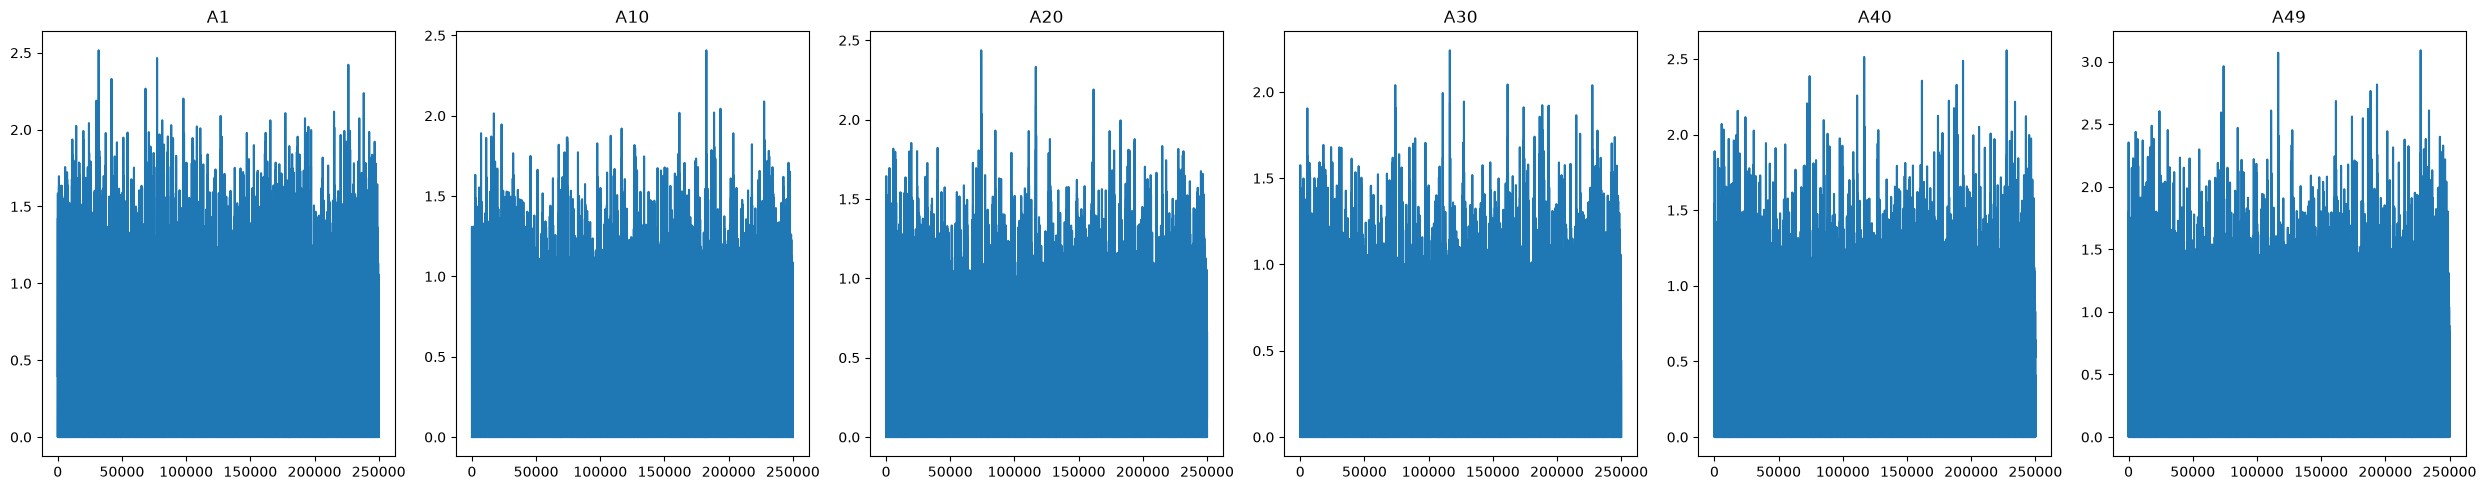

variance of A1: 0.08
variance of A10: 0.0547
variance of A20: 0.0652
variance of A30: 0.0517
variance of A40: 0.0536
variance of A49: 0.0669


In [1073]:
fig, axes = plt.subplots(1, 6, figsize=(25, 5))
A_num_list = [1, 10, 20, 30, 40, 49]
col = 0
for i in range(1, len(node_num_list)):
    if i in A_num_list:
        ax = axes[col]
        A = cache[f'A{i}'].T.flatten().get()
        ax.plot(np.arange(1, len(A)+1), A)
        ax.set_title(f'A{i}')
        col += 1
plt.tight_layout()
plt.show()

for i in A_num_list:
    print(f'variance of A{i}: {cp.round(cp.var(cache[f'A{i}']), 4)}')

We can nearly maintain the variance of $A$ from the initial layer up to the final ReLU layer ($A_{50}$ is the softmax output.)

## 7. Traning in 20 layer model

In [1014]:
node_num_list = [784] + [500]*19 + [10] # 20 layer model
parameters = L_layer_model.initialize_weight(node_num_list)
for i in range(1, len(parameters)//2+1):
    parameters[f'W{i}'] *= np.sqrt(2/node_num_list[i-1])
    
model = L_layer_model.Model(node_num_list)
model.parameters = parameters
epoches = 1000
train_loss, _ = model.train(X_train, y_train, X_train, y_train, 0.01, epoches, True)

cost of 0th epoch: 2.3617
cost of 100th epoch: 0.4856
cost of 200th epoch: 0.0068
cost of 300th epoch: 0.0025
cost of 400th epoch: 0.0014
cost of 500th epoch: 0.0009
cost of 600th epoch: 0.0007
cost of 700th epoch: 0.0005
cost of 800th epoch: 0.0004
cost of 900th epoch: 0.0004


According to the results, we found that the loss decreased faster when using He initialization compared to simply multiplying the weights by 0.1